# Sentiment Analysis

In this notebook we use an RNN network to classify text. The text we will use are IMDB movie reviews and the classification is either positive (1) or negative (0). We employ several different techniques from our other models
* The input lengths vary and there are no windows -- the input is the entire review. This will require the use of "padding" tokens to keep the data stored in a matrix
* The input words are encoded to integers using a tensorflow text vectorization layer.
* These vectors are embedded in a high dimensional vector space using an embedding layer
* The model data is stored as a tensorflow dataset, which allows shuffling, batchig and caching to optimize training time.

In [1]:
import tensorflow_datasets as tfds
import tensorflow as tf

Load the data from tensorflow's own database

In [2]:
raw_train, raw_validation, raw_test = tfds.load(
    name="imdb_reviews",
    split=['train[:80%]', 'train[80%:]', 'test'],
    as_supervised=True
)
print(len(raw_train), len(raw_validation), len(raw_test))

20000 5000 25000


2026-04-08 14:44:57.687300: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-08 14:44:57.687320: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-08 14:44:57.687326: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2026-04-08 14:44:57.687356: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-08 14:44:57.687366: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Clean up html, whitespace, etc

In [3]:
def clean_text(review, label):
    review = tf.strings.regex_replace(review, "<[^>]+>", " ")  # all HTML tags
    review = tf.strings.regex_replace(review, "\\s+", " ")     # collapse whitespace
    return review, label

raw_train = raw_train.map(clean_text)
raw_validation = raw_validation.map(clean_text)
raw_test = raw_test.map(clean_text)

Create datasets that use shuffling, batching and prefetching. (Change the batchsize here if you want)

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_set = raw_train.cache().shuffle(20000).batch(32).prefetch(AUTOTUNE)
valid_set = raw_validation.cache().batch(32).prefetch(AUTOTUNE)
test_set = raw_test.cache().batch(32).prefetch(AUTOTUNE)

Show some of the raw data. Notice the use of `take` to extract data from a tf.dataset

In [5]:
for review, label in raw_train.take(10):
    print(review.numpy().decode("utf-8")) # decode converts a python byte array to correct text
    print(label.numpy())

This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.
0
I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The plot development was co

2026-04-08 14:45:15.622231: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-04-08 14:45:15.622371: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Do some EDA on the dataset. Also note how we access and iterate through the raw data

In [6]:
import matplotlib.pyplot as plt

# Assuming 'train_set' is a tf.data.Dataset with labels (0 or 1)
label_list = []
for _, label in raw_train:
  label_list.append(label.numpy())

2026-04-08 14:45:53.455487: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
%matplotlib inline


## make a histogram of the label_list

In [8]:
review_lengths = []
for review, _ in raw_train:
  review_lengths.append(len(review.numpy()))

## make a histogram of review lengths

2026-04-08 14:46:02.835639: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Is there a correlation between review length and positive/negative?

2026-04-08 14:46:07.147760: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


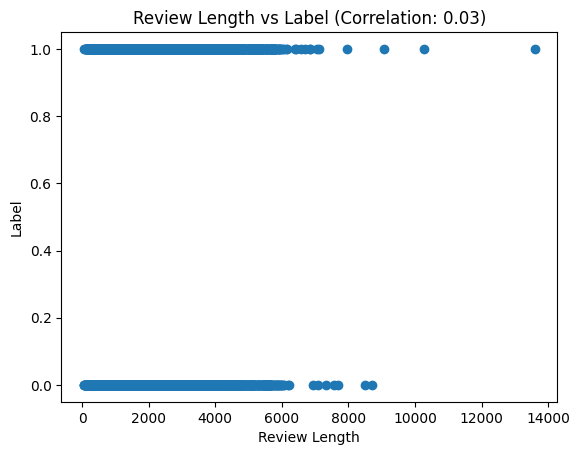

Correlation between review length and label: 0.03


In [9]:
import numpy as np

review_lengths = []
labels = []
for review, label in raw_train:
  review_lengths.append(len(review.numpy()))
  labels.append(label.numpy())

# Calculate correlation
correlation = np.corrcoef(review_lengths, labels)[0, 1]

# Plot review length vs label
plt.scatter(review_lengths, labels)
plt.xlabel("Review Length")
plt.ylabel("Label")
plt.title(f"Review Length vs Label (Correlation: {correlation:.2f})")
plt.show()

print(f"Correlation between review length and label: {correlation:.2f}")


As we have done before using scikit-learn (or manual code), we convert the top 10000 most common vocab terms in the dataset to integers. We will use a tensorflow TextVectorization layer to do so. The layer will take some time to train because of the size of the data. Therefore we show how to save the layer as a tensorflow model for extraction later. Set the 'false' below to 'true' to generate the layer. Be sure to update the filepath and mount Google Drive.

In [16]:
import os
vocab_size = 10000

filepath = "TextVecLayer-IMBD.keras"
rebuild = True
if (rebuild or not os.path.exists(filepath)):
  text_vec_layer = tf.keras.layers.TextVectorization( 
    max_tokens = vocab_size,
  )
  text_vec_layer.adapt(raw_train.map(lambda review, label: review))
    
  # Create model to save TextVectorization Layer
  model = tf.keras.models.Sequential()
  model.add(tf.keras.Input(shape=(1,), dtype=tf.string))
  model.add(text_vec_layer)
    
  # Save.
  model.save(filepath)

2026-04-08 14:53:30.810360: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Now load the layer (from above or an earlier session)

In [17]:
loaded_model = tf.keras.models.load_model(filepath)
text_vec_layer = loaded_model.layers[0]

Let's see how this layer works

In [18]:
text_vec_layer.vocabulary_size()

10000

In [19]:
",".join(text_vec_layer.get_vocabulary()[:100])

',[UNK],the,and,a,of,to,is,in,it,i,this,that,was,as,for,with,movie,but,film,on,not,you,his,are,have,be,he,one,its,at,all,by,an,they,who,from,so,like,her,or,just,about,if,out,has,there,some,what,good,very,more,when,she,my,even,would,up,no,time,which,only,really,story,their,had,see,were,can,me,than,we,much,well,been,get,will,do,also,into,people,other,bad,because,great,first,how,him,most,dont,made,then,movies,them,way,make,films,could,too,any'

Token #1 is UNK, for unknown words (not in the top 1000 vocab). Token 0 is empty space used for padding.

In [20]:
text_vec_layer(["you", 'saw', 'the', 'armadillo', '', '']).numpy()

array([[ 22],
       [209],
       [  2],
       [  1],
       [  0],
       [  0]])

Now create the model. Use the vector layer and an embedding layer. Then a simple GRU stack and a single neuron to classify. Note the use of sigmoid since the output data is a single [0,1] variable.

In [ ]:
import os, datetime

embed_size = 512
model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Embedding(
        input_dim=len(text_vec_layer.get_vocabulary()), 
        output_dim=embed_size,
        mask_zero=True
    ),

    tf.keras.layers.GRU(256),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=3, 
    restore_best_weights=True
)

model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=10, callbacks=[early_stopping])

Epoch 1/10


2026-04-08 14:54:27.088666: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 155ms/step - accuracy: 0.5036 - loss: 0.6935 - val_accuracy: 0.5032 - val_loss: 0.6931
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 229ms/step - accuracy: 0.5519 - loss: 0.6781 - val_accuracy: 0.6858 - val_loss: 0.5970
Epoch 3/10
267/625 ━━━━━━━━━━━━━━━━━━━━ 3:25 573ms/step - accuracy: 0.7923 - loss: 0.4473

### Task

*TO DO*. Run the model on some testing data and print a few of the samples it misclassifies. Read the samples yourself -- do you see why they were misclassified?

In [ ]:
for review, label in raw_test.take(50):
    truth = label.numpy()
    r = [review.numpy()]
    pred = model(tf.constant(r))[0][0].numpy()
    rprep = np.round(pred)
    if (int(truth) != int(rprep)):
        print(label.numpy(), pred)
        print(review.numpy().decode("utf-8")) # decode converts a python byte array to correct text
        print()

In [ ]:
model.evaluate(test_set)

In [ ]:
## Make a confusion matrix for the test set